In [65]:
#!pip3 install tensorflow

In [66]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten, Input

In [67]:
SEED = 123
tf.config.experimental.enable_op_determinism()
tf.random.set_seed(SEED)

In [68]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

In [69]:
X_train[2]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,  67, 232,  39,   0,   0,   0,
          0,   0],
       [  

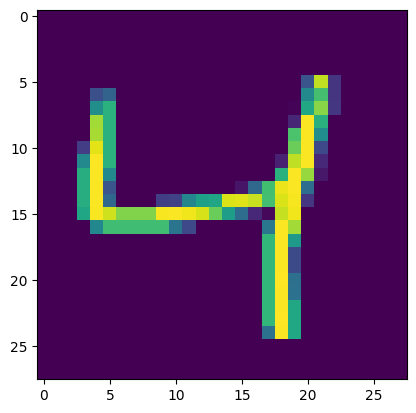

In [70]:
import matplotlib.pyplot as plt
plt.imshow(X_train[2])

In [71]:
X_train[2].shape

(28, 28)

In [72]:
y_train[2]

np.uint8(4)

In [73]:
# Normalise pixel values
X_train, X_test = X_train / 255.0, X_test / 255.0

In [74]:
# Building the neural network
model = Sequential()
model.add(Input(shape=(28, 28)))
model.add(Flatten())                        # 784 input nodes
model.add(Dense(128, activation="relu"))    # 128 hidden nodes
model.add(Dense(32, activation="relu"))     # 32 hidden nodes
model.add(Dense(11, activation="softmax"))  # 11 output nodes
    # Use softmax for multi-class classification
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 11)             │           363 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 104,971 (410.04 KB)

 Trainable params: 104,971 (410.04 KB)

 Non-trainable params: 0 (0.00 B)

In [75]:
# Params include both weights and biases

In [76]:
model.compile(
    loss="sparse_categorical_crossentropy",  # The loss function
    optimizer="Adam",
        # Optimizer is a method to adjust the model's parameters to minimize the loss
    metrics=["accuracy"]   # Metrics we want to track
)
history = model.fit(
    X_train, y_train, epochs=25, validation_split=0.2)

Epoch 1/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 890us/step - accuracy: 0.9170 - loss: 0.2861 - val_accuracy: 0.9577 - val_loss: 0.1435
Epoch 2/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 827us/step - accuracy: 0.9656 - loss: 0.1176 - val_accuracy: 0.9638 - val_loss: 0.1169
Epoch 3/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 816us/step - accuracy: 0.9764 - loss: 0.0804 - val_accuracy: 0.9679 - val_loss: 0.1050
Epoch 4/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 810us/step - accuracy: 0.9827 - loss: 0.0582 - val_accuracy: 0.9713 - val_loss: 0.0953
Epoch 5/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 810us/step - accuracy: 0.9877 - loss: 0.0427 - val_accuracy: 0.9718 - val_loss: 0.0999
Epoch 6/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 808us/step - accuracy: 0.9900 - loss: 0.0337 - val_accuracy: 0.9723 - val_loss: 0.0991
Epoch 7/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 781us/step - accuracy: 0.9916 - loss: 0.0269 - val_accuracy: 0.9722 - val_loss: 0.1052
Epoch 8/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 842us/step - accuracy: 0.9923 -

In [77]:
y_prob = model.predict(X_test)
y_pred = y_prob.argmax(axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 304us/step


2026-01-07 21:03:11.713257: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


In [78]:
y_prob.shape

(10000, 11)

In [79]:
y_pred.shape

(10000,)

In [80]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.9737

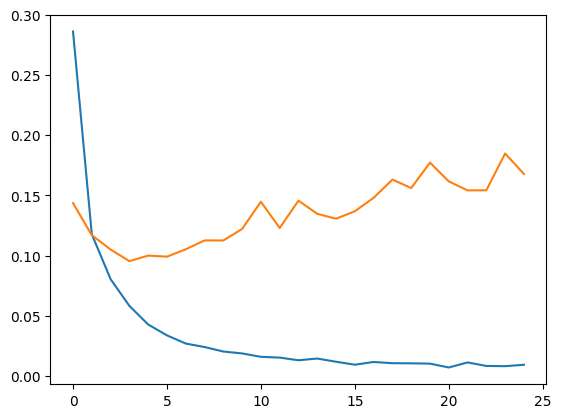

In [81]:
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

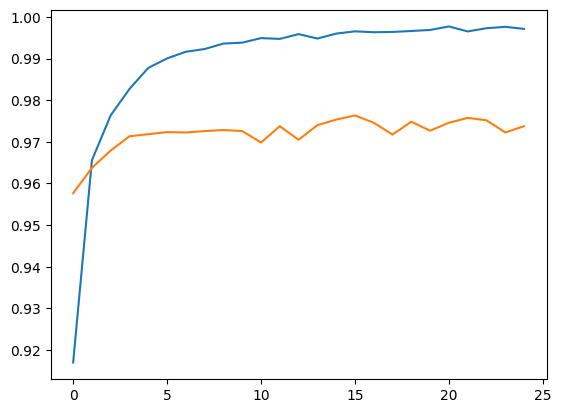

In [82]:
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

In [99]:
import numpy as np
import random

In [105]:
chosen_num = random.randint(0, len(X_test))
print(chosen_num + "n")
chosen_X = X_test[chosen_num:chosen_num+1]
print(model.predict(chosen_X).argmax(axis=1)[0])
plt.imshow(chosen_X[0])

TypeError: unsupported operand type(s) for +: 'int' and 'str'

In [101]:
X_test[chosen_num:chosen_num+1].shape

(1, 28, 28)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


2026-01-07 21:08:07.532452: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


array([7])